# How high was Hurricane Helene's storm surge at Cedar Key?

Hurricane Helene made landfall in Florida's Big Bend late on 26 September 2024
local time. The NOAA tide gauge at Cedar Key (station 8727520) kept recording
through the storm. Its observed water level is the tide plus everything the
storm added; the astronomical tide alone is what CO-OPS predicts from harmonic
constituents. Subtracting the prediction from the observation leaves the
non-tidal residual, which during a landfalling hurricane is dominated by storm
surge.

This study pulls both series and the HURDAT2 best track with one manifest,
finds the peak of the residual, and times it against landfall. The residual at
one gauge is the closest routine measurement of storm surge; it is not a
regional surge height or a return-period estimate. It needs `usdata[pandas]`
and matplotlib; the first run downloads about 7 MB, almost all of it HURDAT2,
and takes a few seconds.

In [1]:
import math
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T05:55:31+00:00
usdata 0.26.0; pandas 3.0.6


## Data

One manifest declares three sources:

- [CO-OPS water levels](https://usdata.dev/datasets/noaa/coops-water-levels/):
  the observed six-minute water level at station 8727520, the quantity the
  storm changed.
- [CO-OPS tide predictions](https://usdata.dev/datasets/noaa/coops-tide-predictions/):
  the six-minute astronomical tide for the same station, the baseline to
  subtract. Both series use the same datum, units, interval, and three UTC
  days, so their rows share timestamps.
- [HURDAT2](https://usdata.dev/datasets/noaa/hurdat2/): the Atlantic best
  track, for the landfall time and the storm's position. It takes no dates,
  because every revision holds the whole record, and the manifest names the
  revision it reads.

Mean lower low water (`MLLW`) is the datum. It cancels in the subtraction but
sets the reference for the plotted heights.

In [2]:
print(manifest.read_text())

name: cedar-key-helene-surge
sources:
  - dataset: noaa:coops-water-levels
    start: 2024-09-25T00:00:00Z
    end: 2024-09-28T00:00:00Z
    params:
      station: "8727520"
      datum: MLLW
      units: metric
  - dataset: noaa:coops-tide-predictions
    start: 2024-09-25T00:00:00Z
    end: 2024-09-28T00:00:00Z
    params:
      station: "8727520"
      datum: MLLW
      units: metric
      interval: "6"
  - dataset: noaa:hurdat2
    params:
      basin: atlantic
      # The 2026-09-12 revision has two upstream typos the reader refuses to guess at.
      revision: 2026-02-27



## Pull and open both series

The first pull writes one lockfile covering all three assets. Index the fetched
items by `dataset_id`, strip NOAA's header spacing from the column names, and
parse the timestamps as UTC (the adapter requests GMT). The observed CSV
carries a `Quality` column of `v` (verified) or `p` (preliminary).

In [3]:
result = pull(manifest)
items = {item.asset.dataset_id: item for item in result.fetched}
assert len(items) == len(result.fetched) == 3, "expected exactly one asset per source"


def series(dataset_id: str) -> pd.DataFrame:
    """Open one CO-OPS CSV with stripped column names and a UTC time index."""
    frame = items[dataset_id].open().rename(columns=str.strip)
    frame["Date Time"] = pd.to_datetime(frame["Date Time"], utc=True)
    return frame.set_index("Date Time")


observed = series("noaa:coops-water-levels")
predicted = series("noaa:coops-tide-predictions")
assert observed.index.equals(predicted.index), "observed and predicted rows must share timestamps"
print(f"Rows: {len(observed)} observed, {len(predicted)} predicted")
print(f"Observed quality flags: {observed['Quality'].value_counts().to_dict()}")
display(observed[["Water Level", "Sigma", "Quality"]].head(3))
display(predicted[["Prediction"]].head(3))

Rows: 721 observed, 721 predicted
Observed quality flags: {'v': 721}


,Water Level,Sigma,Quality
Date Time,,,
2024-09-25 00:00:00+00:00,1.090,0.003,v
2024-09-25 00:06:00+00:00,1.108,0.002,v
2024-09-25 00:12:00+00:00,1.112,0.002,v


,Prediction
Date Time,
2024-09-25 00:00:00+00:00,0.847
2024-09-25 00:06:00+00:00,0.850
2024-09-25 00:12:00+00:00,0.853


In [4]:
for item in result.fetched:
    print(item.asset.dataset_id)
    print(f"Bytes: {item.provenance.size}; cache hit: {item.from_cache}")
    print("Source:", item.provenance.source_url)
    print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
    print("Checksum:", item.provenance.checksum)
    print()

noaa:coops-water-levels
Bytes: 28075; cache hit: False
Source: https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?station=8727520&product=water_level&begin_date=20240925+00%3A00&end_date=20240928+00%3A00&datum=MLLW&units=metric&time_zone=gmt&format=csv&application=usdata
Retrieved (UTC): 2026-09-24T05:55:31+00:00
Checksum: sha256:431fade50c78a7f1ea1f4bf27f40a54fca8809d723d26eb5b4bd7c98623057b2

noaa:coops-tide-predictions
Bytes: 16540; cache hit: False
Source: https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?station=8727520&product=predictions&begin_date=20240925+00%3A00&end_date=20240928+00%3A00&datum=MLLW&units=metric&interval=6&time_zone=gmt&format=csv&application=usdata
Retrieved (UTC): 2026-09-24T05:55:31+00:00
Checksum: sha256:a2002895589d54a1a460b7213ae20c5fcf456cad7fa0373ac9a12aef4870c621

noaa:hurdat2
Bytes: 7082381; cache hit: False
Source: https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2025-02272026.txt
Retrieved (UTC): 2026-09-24T05:55:32+00:00
Checksum: 

## Subtract the tide

The residual is the observed level minus the predicted tide at the same
minute. Its peak is the largest amount of water the storm added on top of the
tide; the peak observed level is what actually stood at the gauge and depends
on where the surge fell in the tidal cycle. Both matter, and they need not
coincide. The residual also includes wind setup, pressure effects, and any
wave setup the gauge resolves, which is why it is called a residual rather
than a surge.

In [5]:
levels = pd.DataFrame({"observed": observed["Water Level"], "predicted": predicted["Prediction"]})
levels["residual"] = levels["observed"] - levels["predicted"]
assert not levels.isna().any().any(), "gaps in the record would need explicit handling"
peak_residual_at = levels["residual"].idxmax()
peak_level_at = levels["observed"].idxmax()
peak = levels.loc[peak_residual_at]
highest = levels.loc[peak_level_at]
print(f"Peak residual: {peak['residual']:.2f} m at {peak_residual_at:%Y-%m-%d %H:%M} UTC")
print(
    f"Peak observed level: {highest['observed']:.2f} m MLLW at {peak_level_at:%Y-%m-%d %H:%M} UTC"
)
print(f"Predicted tide at the peak residual: {peak['predicted']:.2f} m MLLW")
around = slice(
    peak_residual_at - pd.Timedelta(minutes=18), peak_residual_at + pd.Timedelta(minutes=18)
)
levels.loc[around].round(3)

Peak residual: 3.15 m at 2024-09-27 04:54 UTC
Peak observed level: 3.99 m MLLW at 2024-09-27 04:42 UTC
Predicted tide at the peak residual: 0.84 m MLLW


,observed,predicted,residual
Date Time,,,
2024-09-27 04:36:00+00:00,3.986,0.850,3.136
2024-09-27 04:42:00+00:00,3.992,0.847,3.145
2024-09-27 04:48:00+00:00,3.992,0.843,3.149
2024-09-27 04:54:00+00:00,3.990,0.839,3.151
2024-09-27 05:00:00+00:00,3.983,0.835,3.148
2024-09-27 05:06:00+00:00,3.966,0.831,3.135
2024-09-27 05:12:00+00:00,3.950,0.826,3.124


Three days of observed level against the predicted tide, and the difference
between them, with the peak residual marked.

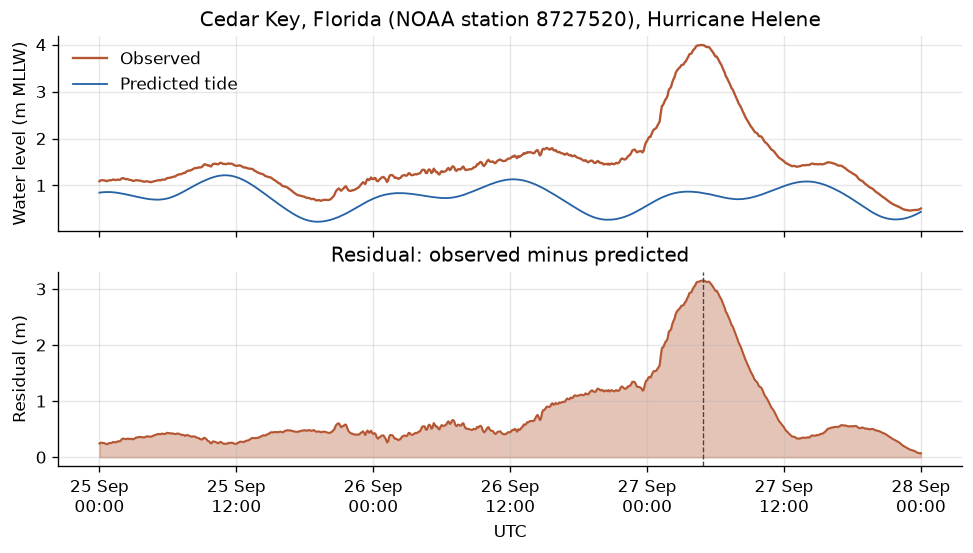

In [6]:
fig, (water, surge) = plt.subplots(2, 1, sharex=True, layout="constrained")
water.plot(levels.index, levels["observed"], color="#b45631", linewidth=1.4, label="Observed")
water.plot(
    levels.index, levels["predicted"], color="#2563a6", linewidth=1.1, label="Predicted tide"
)
water.set_title("Cedar Key, Florida (NOAA station 8727520), Hurricane Helene")
water.set_ylabel("Water level (m MLLW)")
water.legend(loc="upper left", frameon=False)
surge.fill_between(levels.index, 0, levels["residual"], color="#b45631", alpha=0.35)
surge.plot(levels.index, levels["residual"], color="#b45631", linewidth=1.2)
surge.axvline(peak_residual_at, color="#444444", linewidth=0.8, linestyle="--")
surge.set_title("Residual: observed minus predicted")
surge.set_ylabel("Residual (m)")
surge.set_xlabel("UTC")
surge.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M", tz=UTC))
plt.show()

## Place the peak on the best track

HURDAT2 holds one row per best-track point. Select Helene's 2024 track, compute
the great-circle distance from each point to the gauge, and find the landfall
record (`record_identifier` of `L`). Best-track positions are six-hourly plus
special landfall and peak-intensity points, so the storm's position at the
minute of peak residual is interpolated between the bracketing points, not
observed. NOAA lists station 8727520 at 29.135° N, 83.032° W.

In [7]:
GAUGE = (29.135, -83.032)


def distance_km(lat: float, lon: float) -> float:
    """Great-circle distance from the gauge to a point, in kilometres."""
    lat1, lon1, lat2, lon2 = map(math.radians, (GAUGE[0], GAUGE[1], lat, lon))
    half_dlat, half_dlon = (lat2 - lat1) / 2, (lon2 - lon1) / 2
    a = math.sin(half_dlat) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(half_dlon) ** 2
    return 2 * 6371.0 * math.asin(math.sqrt(a))


tracks = items["noaa:hurdat2"].open()
helene = tracks[(tracks["name"] == "HELENE") & (tracks["time"].dt.year == 2024)].copy()
assert len(helene) > 0, "the HURDAT2 revision should include the 2024 season"
helene["distance_km"] = [
    distance_km(lat, lon) for lat, lon in zip(helene["latitude"], helene["longitude"], strict=True)
]
near = (helene["time"] >= peak_residual_at - pd.Timedelta(hours=18)) & (
    helene["time"] <= peak_residual_at + pd.Timedelta(hours=6)
)
columns = ["time", "record_identifier", "status", "latitude", "longitude"]
columns += ["max_wind_kt", "min_pressure_mb", "distance_km"]
window = helene[near]
display(window[columns].assign(distance_km=window["distance_km"].round(1)))

landfalls = helene[helene["record_identifier"] == "L"]
landfall = landfalls.loc[landfalls["distance_km"].idxmin()]
before = helene[helene["time"] <= peak_residual_at].iloc[-1]
after = helene[helene["time"] >= peak_residual_at].iloc[0]
span = after["time"] - before["time"]
fraction = 0.0 if span == pd.Timedelta(0) else (peak_residual_at - before["time"]) / span
storm_lat = before["latitude"] + fraction * (after["latitude"] - before["latitude"])
storm_lon = before["longitude"] + fraction * (after["longitude"] - before["longitude"])
lag_hours = (peak_residual_at - landfall["time"]).total_seconds() / 3600
side = "east" if GAUGE[1] > storm_lon else "west"
winds = "onshore" if GAUGE[1] > storm_lon else "offshore"
print(
    f"Landfall record: {landfall['time']:%Y-%m-%d %H:%M} UTC at "
    f"{landfall['latitude']:.1f}N {abs(landfall['longitude']):.1f}W, "
    f"{landfall['max_wind_kt']:.0f} kt, {landfall['distance_km']:.0f} km from the gauge"
)
print(f"Peak residual came {lag_hours:+.1f} h relative to landfall")
print(
    f"Interpolated storm position at the peak: {storm_lat:.2f}N {abs(storm_lon):.2f}W, "
    f"{distance_km(storm_lat, storm_lon):.0f} km from the gauge"
)
print(f"The gauge lay {side} of the track, on the {winds}-wind side of a northward-moving storm")

,time,record_identifier,status,latitude,longitude,max_wind_kt,min_pressure_mb,distance_km
54956,2024-09-26 12:00:00+00:00,<NA>,HU,24.7,-85.8,85.0,963.0,564.3
54957,2024-09-26 18:00:00+00:00,<NA>,HU,26.6,-85.0,105.0,958.0,341.9
54958,2024-09-27 00:00:00+00:00,<NA>,HU,28.7,-84.3,120.0,941.0,132.6
54959,2024-09-27 03:10:00+00:00,L,HU,30.0,-83.7,120.0,939.0,115.9
54960,2024-09-27 05:00:00+00:00,R,HU,30.8,-83.5,95.0,947.0,190.5
54961,2024-09-27 06:00:00+00:00,<NA>,HU,31.3,-83.3,80.0,957.0,242.1
54962,2024-09-27 09:00:00+00:00,R,TS,32.9,-83.1,60.0,967.0,418.7


Landfall record: 2024-09-27 03:10 UTC at 30.0N 83.7W, 120 kt, 116 km from the gauge
Peak residual came +1.7 h relative to landfall
Interpolated storm position at the peak: 30.76N 83.51W, 186 km from the gauge
The gauge lay east of the track, on the onshore-wind side of a northward-moving storm


## What it shows

The peak residual, the peak observed level, and their timing against the
landfall record. These are one gauge's verified six-minute values relative to
a prediction, not a regional surge height: nearby shorelines saw different
totals, waves add to what a stilling-well gauge records, and a residual also
contains pressure and wind setup that are not surge in the strict sense. The
best track is a post-season reanalysis, so its times and positions are
estimates too.

In [8]:
print(
    f"Helene added {peak['residual']:.2f} m above the predicted tide at Cedar Key, "
    f"peaking at {peak_residual_at:%H:%M} UTC on {peak_residual_at:%d %B %Y}."
)
print(
    f"The water stood {highest['observed']:.2f} m above MLLW at its highest, "
    f"{highest['residual']:.2f} m of which was residual."
)
print(
    f"The peak residual came {lag_hours:.1f} h after the best-track landfall point, "
    f"{landfall['distance_km']:.0f} km away."
)
print("Scope: one verified NOAA gauge, one harmonic prediction, one best-track revision.")

Helene added 3.15 m above the predicted tide at Cedar Key, peaking at 04:54 UTC on 27 September 2024.
The water stood 3.99 m above MLLW at its highest, 3.15 m of which was residual.
The peak residual came 1.7 h after the best-track landfall point, 116 km away.
Scope: one verified NOAA gauge, one harmonic prediction, one best-track revision.


## Pin and cite

`verify` checks the manifest and cached bytes against the lockfile, offline.
A repeat pull restores all three pinned assets from the cache. Keep the
manifest, lockfile, and cached bytes together; the citations below are what a
methods section needs, and `usdata cite dataset.yaml` prints the same.

In [9]:
assert verify(manifest) == []
again = pull(manifest)
print(f"Restored from lockfile: {again.from_lockfile}")
print(f"All assets came from cache: {all(item.from_cache for item in again.fetched)}")
print()
for citation in cite_lockfile(manifest):
    print(citation.as_text())

Restored from lockfile: True
All assets came from cache: True

noaa:coops-water-levels
  NOAA National Ocean Service, Center for Operational Oceanographic Products and Services, observed water levels, accessed via usdata
  homepage: https://api.tidesandcurrents.noaa.gov/api/prod/
  license: US Government Work (public domain)
  terms: https://tidesandcurrents.noaa.gov/disclaimers.html
  retrieved: 2026-09-24; 1 checksummed asset (28,075 bytes) pinned by usdata 0.26.0
  sources: 1
noaa:coops-tide-predictions
  NOAA National Ocean Service, Center for Operational Oceanographic Products and Services, tide predictions, accessed via usdata
  homepage: https://api.tidesandcurrents.noaa.gov/api/prod/
  license: US Government Work (public domain)
  terms: https://tidesandcurrents.noaa.gov/disclaimers.html
  retrieved: 2026-09-24; 1 checksummed asset (16,540 bytes) pinned by usdata 0.26.0
  sources: 2
noaa:hurdat2
  Landsea, C. W. and J. L. Franklin, 2013: Atlantic Hurricane Database Uncertainty 

## What was awkward

- None of the three sources is a fixed file. NOAA re-verifies observations,
  updates the harmonic constituents behind a station's predictions, and
  replaces the HURDAT2 file each season under a new name, so this lockfile
  will go stale. Restoration then exits 4, reports every asset whose bytes
  changed, and rewrites nothing; accepting new bytes is a deliberate
  `usdata pull dataset.yaml --update noaa:hurdat2` (see
  [`--update`](https://docs.usdata.dev/reference/manifests/#pull-refresh-and-restore)).
- The newest HURDAT2 revision (2026-09-12) has two upstream typos the reader
  refuses to guess at, so the manifest pins the 2026-02-27 revision. Moving
  to a newer one means changing that `revision` date first.
- HURDAT2 has no date or storm filter: one storm's track costs the whole
  7 MB Atlantic file.
- CO-OPS column headers carry leading spaces (`" Water Level"`), so every
  frame needs `rename(columns=str.strip)` before use.
- The observed and predicted rows line up only because both requests name the
  same station, datum, units, interval, and bounds; nothing checks that across
  sources, so the notebook asserts it. See the
  [tide-prediction notes](https://docs.usdata.dev/providers/noaa-coops-predictions/)
  for intervals and limits.
- The water-level CSV carries no station position, so the gauge's latitude
  and longitude are typed in from NOAA's station page.